In [1]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from obspy.io.segy.segy import _read_segy
import pylops

plt.close("all")

## Gráfico propagación, corrección NMO hiperbólico y ruido

In [5]:
par = {
    "ox": 0,
    "dx": 2,
    "nx": 201,
    "oy": -100,
    "dy": 2,
    "ny": 101,
    "ot": 0,
    "dt": 0.004,
    "nt": 501,
    "f0": 2,
    "nfmax": 210,
}

vrms = [200]
t0 = [0.5]
amp = [1]

t, t2, x, y = pylops.utils.seismicevents.makeaxis(par)
wav = pylops.utils.wavelets.ricker(np.arange(140) * par["dt"], f0=par["f0"])[0]
mhyp, mhypwav = pylops.utils.seismicevents.hyperbolic2d(x, t, t0, vrms, amp, wav)

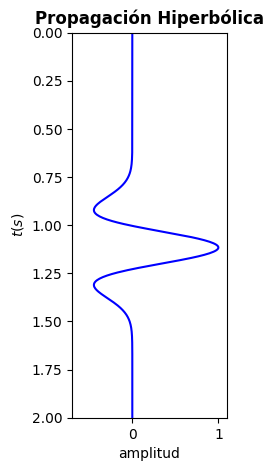

In [86]:
indices = [100]

dt = 2.0 / len(mhypwav[0])

fig, axs = plt.subplots(figsize=(2, 5))
offset = 0

for i in indices:
    y = mhypwav[i] * 1  + offset
    x = np.arange(len(y))
    t = x * dt

    plt.plot(y, t, color="blue")
    offset += 5

axs.set_title("Propagación Hiperbólica", fontsize=12, fontweight="bold")
axs.set_xlabel(r"amplitud")
axs.set_ylabel(r"$t(s)$")

axs.set_ylim(2, 0)
axs.set_xlim(-0.7, 1.1) 
plt.show()

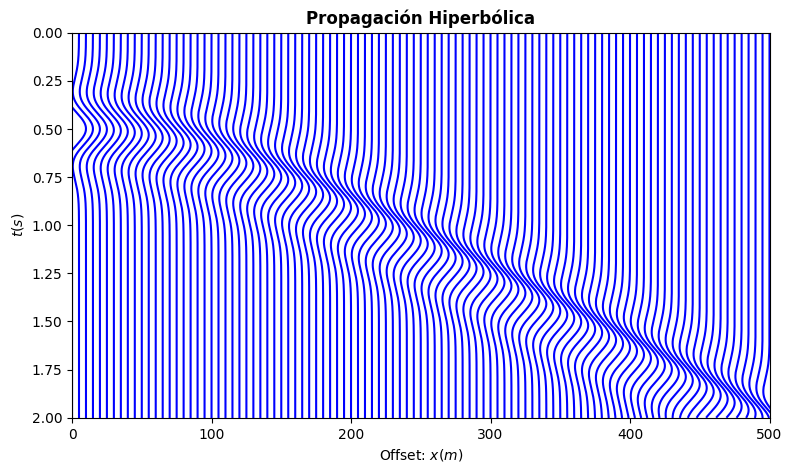

In [89]:
indices = range(0, 201, 2)

dt = 2.0 / len(mhypwav[0])

fig, axs = plt.subplots(figsize=(9, 5))
offset = 0

for i in indices:
    y = mhypwav[i] * 10 + offset
    x = np.arange(len(y))
    t = x * dt

    plt.plot(y, t, color="blue")
    offset += 5

axs.set_title("Propagación Hiperbólica", fontsize=12, fontweight="bold")
axs.set_xlabel(r"Offset: $x(m)$")
axs.set_ylabel(r"$t(s)$")

axs.set_ylim(2, 0)
axs.set_xlim(0, 500) 
plt.show()

In [ ]:
noise = np.random.normal(0, 0.2, size=np.shape(mhypwav))

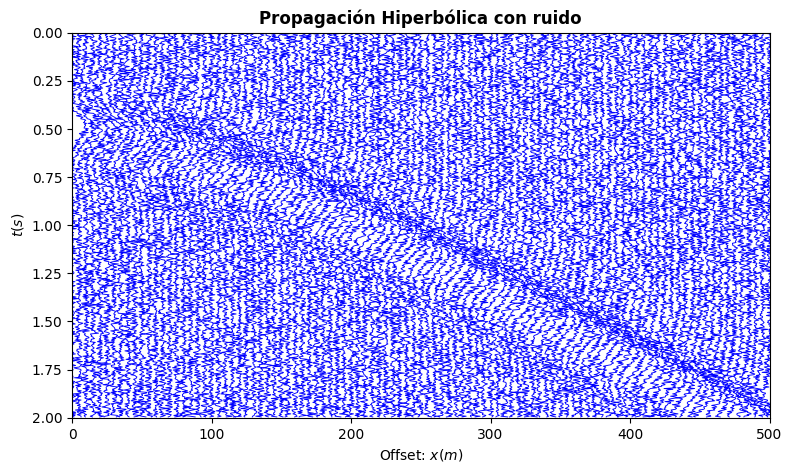

In [116]:
indices = range(0, 201, 2)

dt = 2.0 / len(mhypwav[0])

fig, axs = plt.subplots(figsize=(9, 5))
offset = 0

for i in indices:
    y = mhypwav[i] * 10 + offset + noise[i]*8
    x = np.arange(len(y))
    t = x * dt

    plt.plot(y, t, color="blue", lw=0.65)
    offset += 5

axs.set_title("Propagación Hiperbólica con ruido", fontsize=12, fontweight="bold")
axs.set_xlabel(r"Offset: $x(m)$")
axs.set_ylabel(r"$t(s)$")

axs.set_ylim(2, 0)
axs.set_xlim(0, 500) 
plt.show()

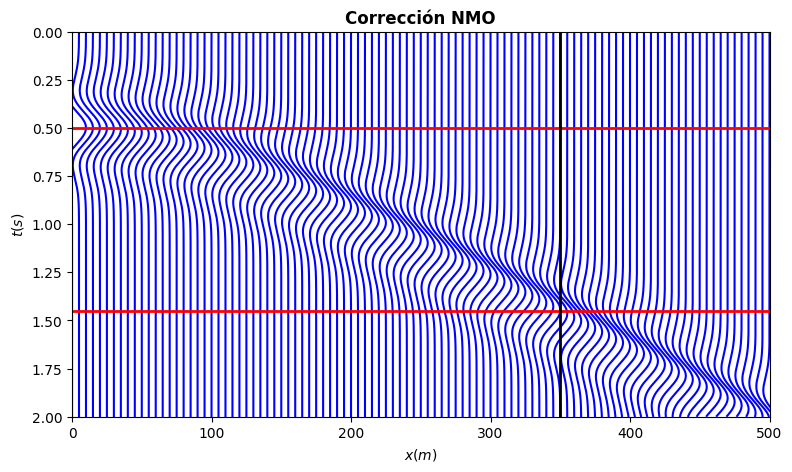

In [70]:
indices = range(0, 201, 2)

dt = 2.0 / len(mhypwav[0])

fig, axs = plt.subplots(figsize=(9, 5))
offset = 0

for i in indices:
    y = mhypwav[i] * 10 + offset
    x = np.arange(len(y))
    t = x * dt

    plt.plot(y, t, color="blue")
    offset += 5

axs.set_title("Corrección NMO", fontsize=12, fontweight="bold")
axs.set_xlabel(r"$x(m)$")
axs.set_ylabel(r"$t(s)$")

plt.axhline(y=0.5, color='r', linewidth=2)
plt.axhline(y=1.45, color='r', linewidth=2)
plt.axvline(x=350, color='black', linestyle='-', linewidth=2)

axs.set_ylim(2, 0)
axs.set_xlim(0, 500) 
plt.show()



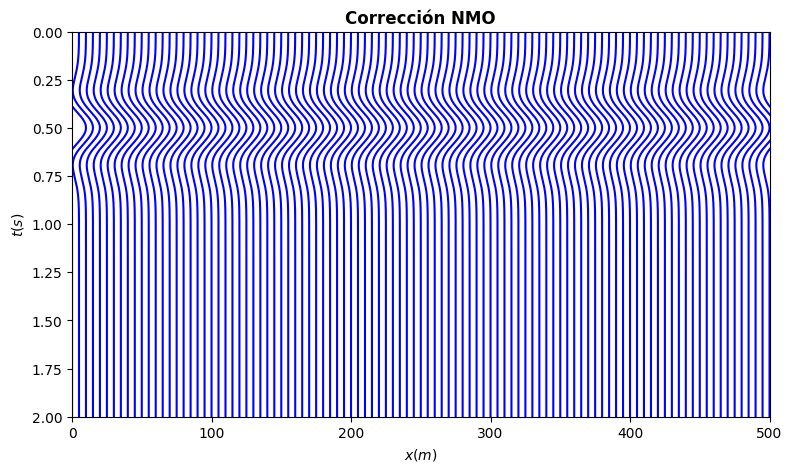

In [101]:
indices = range(0, 201, 2)

dt = 2.0 / len(mhypwav[0])

fig, axs = plt.subplots(figsize=(9, 5))
offset = 0

for i in indices:
    y = mhypwav[0] * 10 + offset
    x = np.arange(len(y))
    t = x * dt

    plt.plot(y, t, color="blue")
    offset += 5

axs.set_title("Corrección NMO", fontsize=12, fontweight="bold")
axs.set_xlabel(r"$x(m)$")
axs.set_ylabel(r"$t(s)$")

axs.set_ylim(2, 0)
axs.set_xlim(0, 500) 
plt.show()


Text(0, 0.5, '$t(s)$')

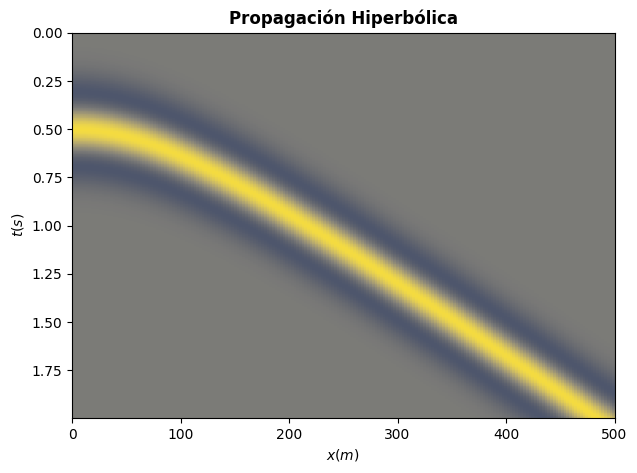

In [102]:
fig, axs = plt.subplots(figsize=(7, 5))
axs.imshow(
    mhypwav.T,
    aspect="auto",
    interpolation="nearest",
    vmin=-1.1,
    vmax=1.1,
    cmap="cividis",
    extent=(x.min(), x.max(), t.max(), t.min()),
)
axs.set_title("Propagación Hiperbólica", fontsize=12, fontweight="bold")
axs.set_xlabel(r"$x(m)$")
axs.set_ylabel(r"$t(s)$")

Text(0, 0.5, '$t(s)$')

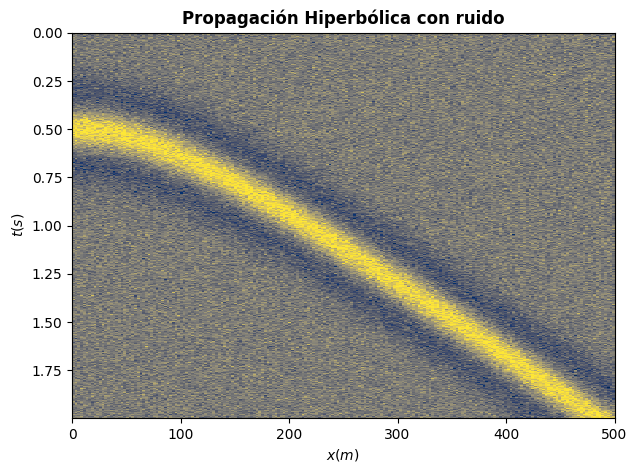

In [105]:
fig, axs = plt.subplots(figsize=(7, 5))
axs.imshow(
    mhypwav.T + noise.T,
    aspect="auto",
    interpolation="nearest",
    vmin=-1.1,
    vmax=1.1,
    cmap="cividis",
    extent=(x.min(), x.max(), t.max(), t.min()),
)
axs.set_title("Propagación Hiperbólica con ruido", fontsize=12, fontweight="bold")
axs.set_xlabel(r"$x(m)$")
axs.set_ylabel(r"$t(s)$")